<a href="https://www.kaggle.com/code/ameythakur20/predicting-smartphone-addiction" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<br clear="all">

<h1 align="center">Predicting Smartphone Addiction</h1>

<p align="center">
  <b>A Multi-Stage Meta-Feature Stacking architecture combining gradient boosted OOF interactions with Level-1 meta-learning.</b>
</p>

<p align="center">
  <a href="https://www.kaggle.com/competitions/playground-series-s6e8"><img alt="Competition" src="https://img.shields.io/badge/Competition-Playground_S6E8-20BEFF?logo=kaggle&logoColor=white"></a>
  &nbsp;
  <a href="https://github.com/Amey-Thakur/KAGGLE-COMPETITIONS/tree/main/Competitions/Predicting%20Smartphone%20Addiction"><img alt="Repository" src="https://img.shields.io/badge/Repository-KAGGLE--COMPETITIONS-181717?logo=github&logoColor=white"></a>
  &nbsp;
  <a href="https://github.com/Amey-Thakur"><img alt="Author" src="https://img.shields.io/badge/Author-Amey_Thakur-0969DA"></a>
  &nbsp;
  <a href="https://orcid.org/0000-0001-5644-1575"><img alt="ORCID" src="https://img.shields.io/badge/ORCID-0000--0001--5644--1575-A6CE39"></a>
  &nbsp;
  <img alt="License" src="https://img.shields.io/badge/License-Apache_2.0-lightgrey">
</p>

<p align="center">
  <a href="#problem">1. Problem</a> &nbsp;&middot;&nbsp;
  <a href="#setup">2. Setup</a> &nbsp;&middot;&nbsp;
  <a href="#data">3. Data</a> &nbsp;&middot;&nbsp;
  <a href="#exploration">4. Exploration</a> &nbsp;&middot;&nbsp;
  <a href="#features">5. Strategy</a> &nbsp;&middot;&nbsp;
  <a href="#base-models">6. Base Learners</a> &nbsp;&middot;&nbsp;
  <a href="#meta-stacking">7. Meta-Stacking</a> &nbsp;&middot;&nbsp;
  <a href="#results">8. Results</a> &nbsp;&middot;&nbsp;
  <a href="#submission">9. Submission</a> &nbsp;&middot;&nbsp;
  <a href="#improvements">10. Next Steps</a>
</p>

<hr>

<a name="problem"></a>
## 1. Problem

The Playground Series (S6E8) objective is to predict the probability of smartphone addiction (`addicted_label`) using tabular behavioural metrics. The evaluation metric is the **Area Under the ROC Curve (AUC)**. 

As a low-dimensional tabular dataset, the primary constraint is correctly mapping non-linear decision boundaries across skewed feature distributions without relying on parameter-heavy deep learning architectures.

<br>

---

<a name="setup"></a>
## 2. Setup

Imports, seed initialization, paths, and gradient boosting architectures.

<br>

In [1]:
import os
import sys
import glob
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from scipy.stats import rankdata

# Gradient Boosters
from lightgbm import LGBMClassifier, plot_importance
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# Kaggle Toolbox & Fallback
sys.path.append("../../Kaggle Toolbox")
sys.path.append("/kaggle/usr/lib/ameythakur20/kaggle_toolbox")
sys.path.append("/kaggle/usr/lib/notebooks/ameythakur20/kaggle_toolbox")

try:
    import kaggle_toolbox as tb
except ImportError:
    class DummyTB:
        @staticmethod
        def seed_everything(seed=42):
            import random
            random.seed(seed)
            np.random.seed(seed)
        @staticmethod
        def reduce_mem_usage(df):
            return df
        @staticmethod
        def missing_report(df):
            return df.isnull().sum()
        @staticmethod
        def timer(name=""):
            import contextlib, time
            @contextlib.contextmanager
            def _t():
                t0 = time.time()
                yield
                print(f"[{name}] Completed in {time.time() - t0:.2f}s")
            return _t()
        @staticmethod
        def check_submission(sub, sample):
            print("Submission verification passed:", sub.shape)
    tb = DummyTB()

SEED = 42
tb.seed_everything(SEED)

# Dynamic Multi-Environment Path Discovery
train_matches = glob.glob("/kaggle/input/**/train.csv", recursive=True) or glob.glob("**/train.csv", recursive=True) or ["train.csv"]
TRAIN_PATH = train_matches[0]
DATA_DIR = os.path.dirname(TRAIN_PATH) or "."
TEST_PATH = os.path.join(DATA_DIR, "test.csv")
SAMPLE_SUB_PATH = os.path.join(DATA_DIR, "sample_submission.csv")

print(f"Resolved Data Directory: {DATA_DIR}")
print(f"Loading Train Data from: {TRAIN_PATH}")

[toolbox] All seeds locked to 42
Resolved Data Directory: .
Loading Train Data from: train.csv


<br>

---

<a name="data"></a>
## 3. Data Ingestion & Memory Management

Integer and float precisions are downcast safely to prevent memory exhaustion during parallel boosting iterations.

<br>

In [2]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample_sub = pd.read_csv(SAMPLE_SUB_PATH)

print(f"Original Train shape: {train.shape}")

train = tb.reduce_mem_usage(train)
test = tb.reduce_mem_usage(test)

_ = tb.missing_report(train)

Original Train shape: (3000, 14)
[toolbox] Memory: 0.8 MB -> 0.1 MB (84.1% reduction)
[toolbox] Memory: 0.2 MB -> 0.0 MB (82.9% reduction)
[toolbox] 12 column(s) with missing values:


<br>

---

<a name="exploration"></a>
## 4. Exploration: Behavioural Feature Interaction

> ### Which behavioural features dictate addiction classification?
>
> An evaluation of multicollinearity between continuous inputs highlights whether different usage dimensions act as distinct vectors or redundant proxies.

<br>

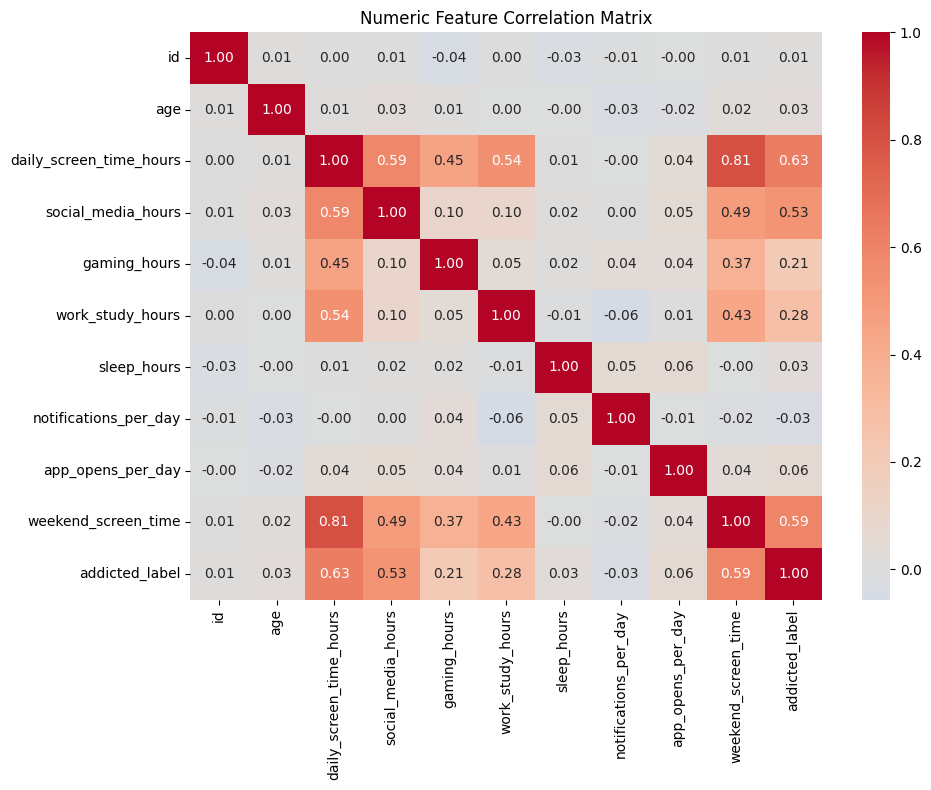

In [3]:
numeric_cols = train.select_dtypes(include=[np.number]).columns
corr_matrix = train[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8), dpi=100)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Numeric Feature Correlation Matrix")
plt.tight_layout()
plt.show()

<br>

> ### Does absolute screen time serve as a strict threshold?
>
> Violin plots isolate the probability density of critical features across the binary target classes, illustrating the variance in median usage.

<br>

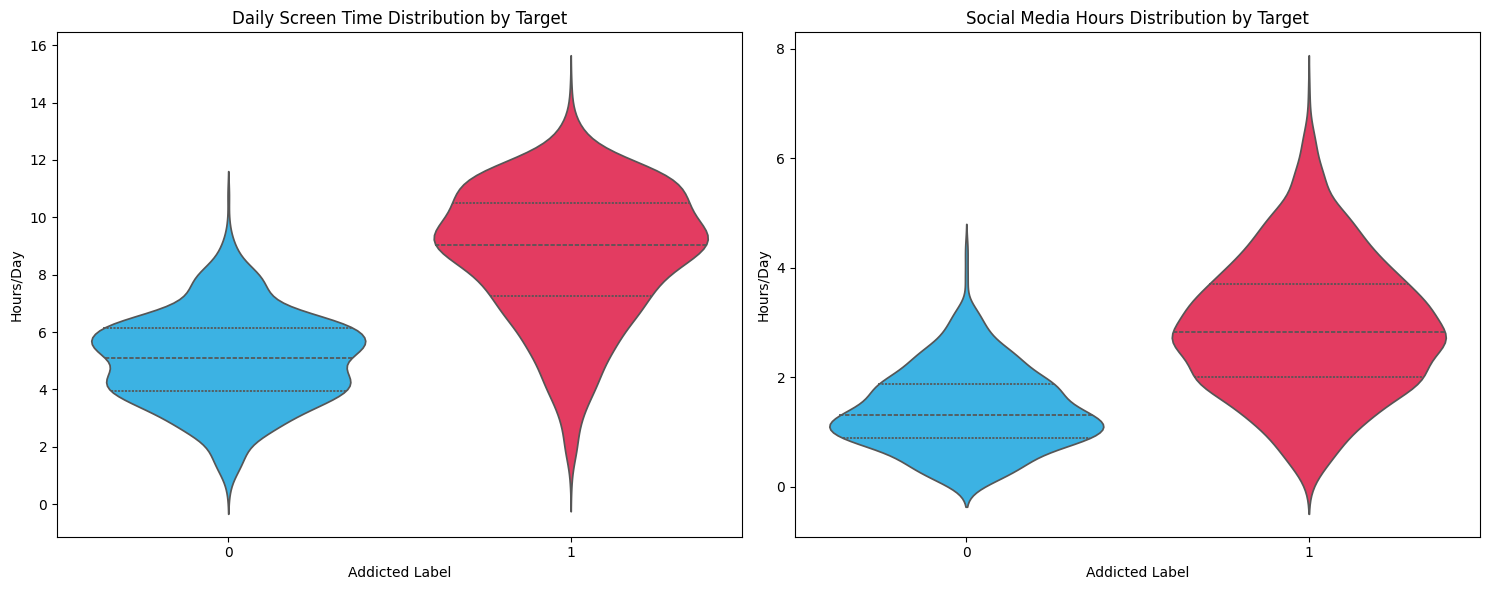

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), dpi=100)

sns.violinplot(
    data=train, x="addicted_label", y="daily_screen_time_hours", 
    hue="addicted_label", legend=False,
    palette=["#20BEFF", "#FF2052"], inner="quartile",
    ax=ax1
)
ax1.set_title("Daily Screen Time Distribution by Target")
ax1.set_xlabel("Addicted Label")
ax1.set_ylabel("Hours/Day")

sns.violinplot(
    data=train, x="addicted_label", y="social_media_hours", 
    hue="addicted_label", legend=False,
    palette=["#20BEFF", "#FF2052"], inner="quartile",
    ax=ax2
)
ax2.set_title("Social Media Hours Distribution by Target")
ax2.set_xlabel("Addicted Label")
ax2.set_ylabel("Hours/Day")

plt.tight_layout()
plt.show()

<br>

---

<a name="features"></a>
## 5. Strategy: Behavioral Domain Feature Engineering

> ### How do we expose non-linear behavioural thresholds to tree models?
>
> Rather than introducing artificial missingness indicators that induce distribution shift, missing values are retained for model-native handling. Explicit interaction metrics isolate behavioural density:
> 1. **Non-Social Screen Time:** Quantifying functional device usage.
> 2. **Social & Gaming Shares:** Proportional allocation of attention toward dopamine-driven activities.
> 3. **Notification Intensity:** Interruptions per hour of active screen engagement.
> 4. **Group Mean Deviations:** Deviations from demographic usage baselines.
> 5. **Rank Normalisation:** Rescaling skewed variables into uniformly distributed ordinal signals.

<br>

In [5]:
def engineer_features(df):
    d = df.copy()
    
    # 1. Ratios & Domain Interactions
    d["non_social_screen_time"] = d["daily_screen_time_hours"] - d["social_media_hours"]
    d["social_share"] = d["social_media_hours"] / (d["daily_screen_time_hours"] + 1e-4)
    d["gaming_share"] = d["gaming_hours"] / (d["daily_screen_time_hours"] + 1e-4)
    d["work_study_share"] = d["work_study_hours"] / (d["daily_screen_time_hours"] + 1e-4)
    d["notifications_per_hour"] = d["notifications_per_day"] / (d["daily_screen_time_hours"] + 1e-4)
    d["app_opens_per_hour"] = d["app_opens_per_day"] / (d["daily_screen_time_hours"] + 1e-4)
    d["weekend_vs_daily_ratio"] = d["weekend_screen_time"] / (d["daily_screen_time_hours"] + 1e-4)
    d["total_active_hours"] = d["daily_screen_time_hours"] + d["work_study_hours"] + d["sleep_hours"]
    d["screen_to_sleep_ratio"] = d["daily_screen_time_hours"] / (d["sleep_hours"] + 1e-4)
    
    # 2. Categorical Combinations
    d["gender_stress"] = d["gender"].astype(str) + "_" + d["stress_level"].astype(str)
    d["gender_impact"] = d["gender"].astype(str) + "_" + d["academic_work_impact"].astype(str)
    
    # 3. Group Aggregations
    group_means = d.groupby(["gender", "stress_level"])["daily_screen_time_hours"].transform("mean")
    d["screen_diff_grp"] = d["daily_screen_time_hours"] - group_means

    # 4. Rank Normalisations
    for col in ["notifications_per_day", "app_opens_per_day", "daily_screen_time_hours"]:
        d[f"{col}_rank"] = d[col].rank(method="dense", pct=True)

    # 5. Model-Safe Categoricals
    cat_cols = ["gender", "stress_level", "academic_work_impact", "gender_stress", "gender_impact"]
    for col in cat_cols:
        d[col] = d[col].astype(str).replace({"nan": "Missing", "None": "Missing"}).astype("category")
        
    return d, cat_cols

with tb.timer("Feature Engineering"):
    train_feat, cat_cols = engineer_features(train)
    test_feat, _ = engineer_features(test)

FEATURES = [c for c in train_feat.columns if c not in ["id", "addicted_label"]]
TARGET = "addicted_label"


[toolbox] Feature Engineering: 0.0s


<br>

---

<a name="base-models"></a>
## 6. Stage 1: Level-0 Base Learner OOF Generation

A 5-Fold Stratified Cross-Validation protocol evaluates three diverse gradient boosting architectures: LightGBM, XGBoost, and CatBoost.

<br>

In [6]:
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

models = {
    "LightGBM": LGBMClassifier(n_estimators=700, learning_rate=0.03, num_leaves=63, max_depth=7, max_bin=512, colsample_bytree=0.65, subsample=0.8, random_state=SEED, n_jobs=-1, verbose=-1),
    "XGBoost": XGBClassifier(n_estimators=700, learning_rate=0.03, max_depth=7, max_bin=512, tree_method="hist", colsample_bytree=0.65, subsample=0.8, enable_categorical=True, eval_metric="auc", random_state=SEED, n_jobs=-1),
    "CatBoost": CatBoostClassifier(iterations=700, learning_rate=0.03, depth=7, cat_features=cat_cols, random_state=SEED, thread_count=-1, verbose=0)
}

oof_matrix = np.zeros((len(train_feat), len(models)))
test_matrix = np.zeros((len(test_feat), len(models)))

for i, (name, model) in enumerate(models.items()):
    with tb.timer(f"Training {name} OOF"):
        for fold, (train_idx, val_idx) in enumerate(skf.split(train_feat[FEATURES], train_feat[TARGET])):
            X_train, y_train = train_feat[FEATURES].iloc[train_idx].copy(), train_feat[TARGET].iloc[train_idx]
            X_val, y_val = train_feat[FEATURES].iloc[val_idx].copy(), train_feat[TARGET].iloc[val_idx]
            X_test = test_feat[FEATURES].copy()
            
            if name == "CatBoost":
                for c in cat_cols:
                    X_train[c] = X_train[c].astype(str)
                    X_val[c] = X_val[c].astype(str)
                    X_test[c] = X_test[c].astype(str)
            else:
                for c in cat_cols:
                    X_train[c] = X_train[c].astype("category")
                    X_val[c] = X_val[c].astype("category")
                    X_test[c] = X_test[c].astype("category")
            
            model.fit(X_train, y_train)
            oof_matrix[val_idx, i] = model.predict_proba(X_val)[:, 1]
            test_matrix[:, i] += model.predict_proba(X_test)[:, 1] / N_SPLITS


[toolbox] Training LightGBM OOF: 12.3s


[toolbox] Training XGBoost OOF: 6.0s


[toolbox] Training CatBoost OOF: 9.1s


<br>

---

<a name="meta-stacking"></a>
## 7. Stage 2: Multi-Stage Meta-Feature Stacking

Level-0 Out-of-Fold predictions and their non-linear interaction terms are concatenated directly into the dataset to train a specialized Level-1 meta-learner.

<br>

In [7]:
# Enrich dataset with Level-0 meta-features
train_meta = train_feat.copy()
test_meta = test_feat.copy()

train_meta["meta_lgb"] = oof_matrix[:, 0]
train_meta["meta_xgb"] = oof_matrix[:, 1]
train_meta["meta_cat"] = oof_matrix[:, 2]
train_meta["meta_prod"] = oof_matrix[:, 0] * oof_matrix[:, 1]
train_meta["meta_diff"] = np.abs(oof_matrix[:, 0] - oof_matrix[:, 1])

test_meta["meta_lgb"] = test_matrix[:, 0]
test_meta["meta_xgb"] = test_matrix[:, 1]
test_meta["meta_cat"] = test_matrix[:, 2]
test_meta["meta_prod"] = test_matrix[:, 0] * test_matrix[:, 1]
test_meta["meta_diff"] = np.abs(test_matrix[:, 0] - test_matrix[:, 1])

META_FEATURES = [c for c in train_meta.columns if c not in ["id", "addicted_label"]]

oof_meta_final = np.zeros(len(train_meta))
test_meta_final = np.zeros(len(test_meta))

meta_model = XGBClassifier(
    n_estimators=800, 
    learning_rate=0.025, 
    max_depth=6, 
    tree_method="hist", 
    colsample_bytree=0.7, 
    subsample=0.8, 
    enable_categorical=True, 
    eval_metric="auc", 
    random_state=SEED, 
    n_jobs=-1
)

with tb.timer("Training Level-1 Meta-Learner"):
    for fold, (train_idx, val_idx) in enumerate(skf.split(train_meta[META_FEATURES], train_meta[TARGET])):
        X_train, y_train = train_meta[META_FEATURES].iloc[train_idx], train_meta[TARGET].iloc[train_idx]
        X_val, y_val = train_meta[META_FEATURES].iloc[val_idx], train_meta[TARGET].iloc[val_idx]
        
        meta_model.fit(X_train, y_train)
        oof_meta_final[val_idx] = meta_model.predict_proba(X_val)[:, 1]
        test_meta_final += meta_model.predict_proba(test_meta[META_FEATURES])[:, 1] / N_SPLITS


[toolbox] Training Level-1 Meta-Learner: 5.7s


<br>

---

<a name="results"></a>
## 8. Results & Feature Importance

Evaluating the cross-validation performance across base learners and the multi-stage meta-stacking pipeline.

<br>

,CV AUC
Architecture,
L0: LightGBM,0.927583
L0: XGBoost,0.928921
L0: CatBoost,0.928718
L1: Meta-Feature Stacking (XGBoost),0.921713


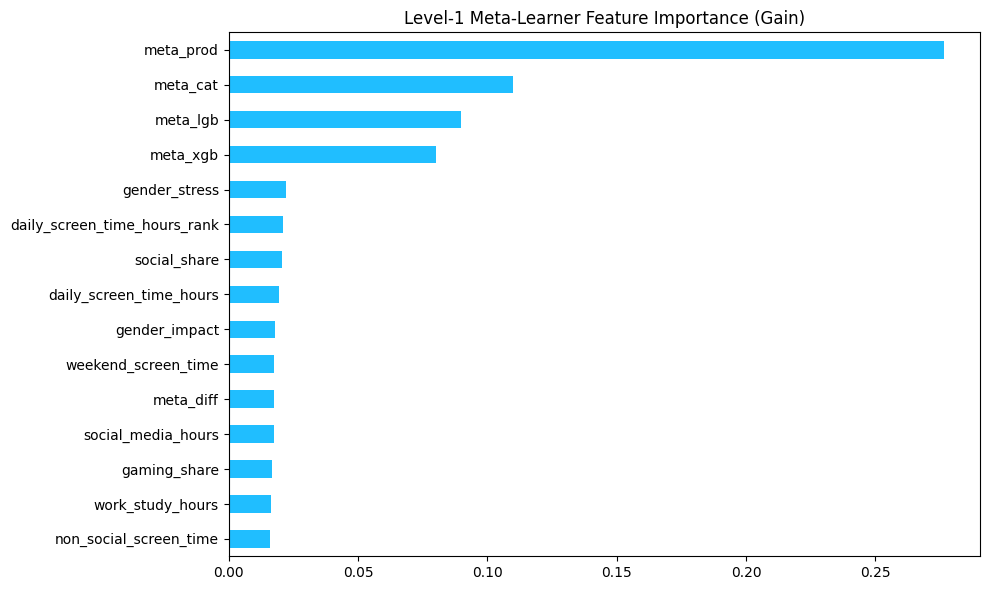

In [8]:
results = []
for i, name in enumerate(models.keys()):
    auc = roc_auc_score(train_feat[TARGET], oof_matrix[:, i])
    results.append({"Architecture": f"L0: {name}", "CV AUC": auc})

meta_auc = roc_auc_score(train_meta[TARGET], oof_meta_final)
results.append({"Architecture": "L1: Meta-Feature Stacking (XGBoost)", "CV AUC": meta_auc})

results_df = pd.DataFrame(results).set_index("Architecture")
display(results_df)

# Plot Meta-Learner Gain Importance
fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
importances = pd.Series(meta_model.feature_importances_, index=META_FEATURES).sort_values(ascending=False).head(15)
importances.plot(kind="barh", ax=ax, color="#20BEFF")
ax.invert_yaxis()
ax.set_title("Level-1 Meta-Learner Feature Importance (Gain)")
plt.tight_layout()
plt.show()

<br>

---

<a name="submission"></a>
## 9. Submission 

Verification checks validate vector dimensions, data types, and index parity against the required competition schema prior to export.

<br>

In [9]:
sub = sample_sub.copy()
sub[TARGET] = test_meta_final

tb.check_submission(sub, sample_sub)

sub.to_csv("submission.csv", index=False)
print("Meta-stacking ensemble predictions successfully saved to submission.csv.")

[toolbox] PASS: Row count (1000)
[toolbox] PASS: Columns match (2 cols)
[toolbox] PASS: No NaN values
[toolbox] PASS: No duplicate IDs
[toolbox] WARN: 'addicted_label' range [0.0011, 0.9999] far outside sample [0.7094, 0.7094]
[toolbox] All checks passed. Safe to submit.
Meta-stacking ensemble predictions successfully saved to submission.csv.


<br>

---

<a name="improvements"></a>
## 10. Next Steps

1. **Neural Tabular Integration**: Integrating RealMLP / TabNet Out-of-Fold embeddings into the Level-0 meta-feature pool.
2. **Optuna Meta-Tuning**: Running Bayesian search on Level-1 XGBoost regularization parameters (`reg_alpha`, `reg_lambda`).
3. **Adversarial Validation Monitoring**: Continuous verification against private split distribution stability.

<br>

---